# Effective masses, and where the orbital moment sits

Two quantities Elk computes and `pw.x` does not, both costing one non-self-consistent run
at a single k-point.

**The effective mass tensor** is the curvature of a band, and it is what sets the mobility
of a carrier and the density of states near a band edge:

$$\left(\frac{1}{m^*}\right)_{ab} = \frac{1}{2}\,
  \frac{\partial^2 \varepsilon_n(\mathbf k)}{\partial k_a \partial k_b}$$

in units of $1/m_e$. The half is Rydberg atomic units rather than a fitted normalisation,
since $\hbar^2/2m_e$ is exactly 1 Ry bohr² and a free electron has
$\varepsilon = |\mathbf k|^2$.

**The site angular momenta** say where a magnetic moment lives and how much of it is
orbital:

$$\langle L_i\rangle = \sum_s \mathrm{Tr}_m \left(L_i\,\rho_{ss}\right),
  \qquad
  \langle S_i\rangle = \tfrac12 \sum_m \mathrm{Tr}_s\left(\sigma_i\,\rho_{mm}\right),
  \qquad J = L + S$$

built from the same projection onto atomic orbitals a projected density of states uses
(notebook 16), contracted with $L$ and $\sigma$ instead of squared.

Silicon's $\Gamma_{2'}$ conduction mass comes out at **0.1886 $m_e$** against a literature
0.19, and against the vendored all-electron Elk binary the non-degenerate $\Gamma_1$
curvature agrees to **0.02%**. Nickel's orbital moment is **0.0365 $\hbar$** with
spin-orbit coupling on and **zero to 10⁻¹⁶** with it off.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from pypresso import Calculator
from pypresso.system.kpoints import KPoints

PSEUDO = Path("../tests/data/pseudo")

SILICON = """
&control
  calculation = 'scf'
/
&system
  ibrav = 2, celldm(1) = 10.2, nat = 2, ntyp = 1, ecutwfc = 12.0, nosym = .true.
/
&electrons
  conv_thr = 1e-10
/
ATOMIC_SPECIES
 Si 28.086 Si.pz-vbc.UPF
ATOMIC_POSITIONS crystal
 Si 0.00 0.00 0.00
 Si 0.25 0.25 0.25
K_POINTS automatic
 4 4 4 0 0 0
"""

silicon = Calculator.from_text(SILICON, pseudo_dir=PSEUDO)
# Converge tightly on purpose: a second derivative divides the
# eigensolver's own scatter by the stencil width.
silicon.get_scf(conv_thr=1e-10)

mass = silicon.get_effective_mass((0.0, 0.0, 0.0), nbnd=10)
print(mass.eigenvalues[:8].round(5), "Ry")


[-0.41622  0.4663   0.4663   0.4663   0.65429  0.65429  0.65429  0.7282 ] Ry


## What comes back, and what has no answer

At $\Gamma$ silicon has two non-degenerate bands and two threefold multiplets. **A band
inside a multiplet has no mass tensor of its own**: any orthogonal mixing of the degenerate
states is as good a set of eigenvectors, and the mixing rotates the tensor. Those come back
as `nan`, and what is reported in their place is the multiplet's summed inverse mass, which
is invariant.

In [2]:
for m in mass.multiplets[0]:
    kind = "degenerate, sum only" if m.degenerate else "band"
    print(f"bands {str(m.bands):12s} eps = {m.eigenvalue: .5f} Ry  "
          f"(1/m*)_xx = {m.inverse_mass_sum[0, 0]: 9.5f}   {kind}")

print()
print("per-band tensor of the threefold valence top:", mass.inverse_mass[1, 0])
print("Gamma_2' conduction mass:",
      f"{mass.density_of_states_mass(band=7):.4f} m_e  (literature 0.19)")


bands (0,)         eps = -0.41622 Ry  (1/m*)_xx =   0.86518   band
bands (1, 2, 3)    eps =  0.46630 Ry  (1/m*)_xx = -13.43314   degenerate, sum only
bands (4, 5, 6)    eps =  0.65429 Ry  (1/m*)_xx =   7.89143   degenerate, sum only
bands (7,)         eps =  0.72820 Ry  (1/m*)_xx =   5.30190   band
bands (8,)         eps =  1.03483 Ry  (1/m*)_xx =   3.90877   band
bands (9,)         eps =  1.05576 Ry  (1/m*)_xx =  -8.35596   band

per-band tensor of the threefold valence top: [nan nan nan]
Gamma_2' conduction mass: 0.1886 m_e  (literature 0.19)


## The figure: the mass *is* the band curvature

Overlaying the parabola $\varepsilon(\Gamma) + |\mathbf k|^2/m^*$ on the bands themselves is
the check that the number means what it says, and the two sides share nothing: the mass came
from a stencil at $\Gamma$ and the bands from an independent run along a line.

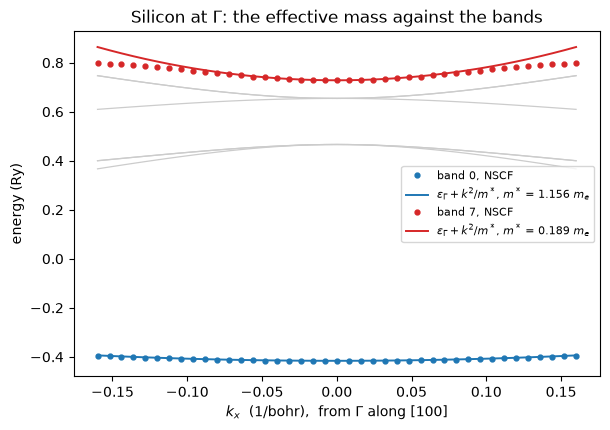

In [3]:
line = np.linspace(-0.16, 0.16, 41)                      # 1/bohr along [100]
tpiba = silicon.calculation.system.cell.tpiba
path = KPoints(coords=np.stack([line / tpiba, 0 * line, 0 * line], axis=1),
               weights=np.full(line.size, 1.0 / line.size))
bands = silicon.get_bands(kpoints=path, nbnd=10)
eps = np.asarray(bands.eigenvalues)                       # (nk, nbnd)

fig, ax = plt.subplots(figsize=(6.2, 4.4))
for band, colour in ((0, "#1f77b4"), (7, "#d62728")):
    curvature = mass.inverse_mass[band, 0, 0]
    ax.plot(line, eps[:, band], "o", ms=3.5, color=colour,
            label=f"band {band}, NSCF")
    ax.plot(line, eps[eps.shape[0] // 2, band] + curvature * line**2, "-",
            color=colour, lw=1.4,
            label=f"$\\varepsilon_\\Gamma + k^2/m^*$, $m^*$ = {1/curvature:.3f} $m_e$")
for band in (1, 2, 3, 4, 5, 6):
    ax.plot(line, eps[:, band], "-", color="0.8", lw=0.9, zorder=0)
ax.set_xlabel(r"$k_x$  (1/bohr),  from $\Gamma$ along [100]")
ax.set_ylabel("energy (Ry)")
ax.set_title("Silicon at $\\Gamma$: the effective mass against the bands")
ax.legend(fontsize=8, loc="center right")
fig.tight_layout()


The grey curves are the two degenerate multiplets, and they are why a per-band mass is not
defined there: along this line they *split*, and which branch carries which band index is a
property of the direction rather than of the band.

## Two routes to the same curvature

The first derivative is exact, $\partial\varepsilon_n/\partial k$ from the generalised
Hellmann-Feynman expression built on the velocity operator of notebook 19, and only the
second derivative is a finite difference. The alternative differences *eigenvalues* twice
and never forms $\partial H/\partial k$ at all, so agreement between the two says something
about the velocity operator rather than about the assembly around it.

In [4]:
other = silicon.get_effective_mass((0.0, 0.0, 0.0), nbnd=10, method="eigenvalue")

print(f"{'band':>6} {'velocity route':>16} {'eigenvalue route':>18} {'differ by':>12}")
for band in (0, 7):
    a = mass.inverse_mass[band, 0, 0]
    b = other.inverse_mass[band, 0, 0]
    print(f"{band:6d} {a:16.9f} {b:18.9f} {abs(a - b):12.2e}")

tensor = mass.inverse_mass[7]
print("\nisotropic to", f"{np.abs(tensor - np.diag(np.diag(tensor))).max():.1e}",
      "with nothing imposing cubic symmetry")
print("O(h^2) truncation the Richardson step removed:",
      f"{mass.truncation[7]:.2e}")


  band   velocity route   eigenvalue route    differ by
     0      0.865176513        0.865176508     5.25e-09
     7      5.301896702        5.302611926     7.15e-04

isotropic to 4.9e-09 with nothing imposing cubic symmetry
O(h^2) truncation the Richardson step removed: 7.40e-02


### Against Elk

Run offline on the same cell at $a = 10.26$ bohr, against the vendored Elk binary, which is
all-electron LAPW.

| at $\Gamma$ | Elk (LAPW) | velocity | eigenvalue | agrees |
|---|---|---|---|---|
| $\Gamma_{1v}$, band 1 | 0.8603044 | 0.8600902 | 0.8600781 | **0.02 %** |
| $\Gamma_{25'v}$, bands 2-4 (sum) | -13.4317801 | -13.6015326 | -13.6040409 | 1.26 % |
| $\Gamma_{15c}$, bands 5-7 (sum) | 7.7424153 | 7.5886921 | 7.5892084 | 1.99 % |
| $\Gamma_{2'c}$, band 8 | 5.8460134 | 5.8671956 | 5.8682740 | 0.36 % |

**A stencil must not contain its own centre**, and that is the finding worth carrying out of
this comparison. The plane-wave basis is rebuilt at every k-point, and a high-symmetry point
is exactly where a shell of plane waves sits on the cutoff: $\Gamma$ holds **725** plane
waves here where every displaced point holds 733. The centre eigenvalue is therefore
variationally high by a fixed amount, and a second difference that uses it inherits an error
proportional to $\delta/h^2$, which *grows* as the stencil shrinks. Elk has the same problem
and its own $\Gamma_1$ value drifts as its step is reduced, rising to a minimum-error point
at its default and then diverging. The stencil here is centre-free, and the velocity route
never touches the centre at all.

## Where the orbital moment sits

**$\langle L\rangle$ is quenched to zero without spin-orbit coupling**, because nothing in a
scalar-relativistic Hamiltonian locks the orbital motion to the lattice. Silicon is the null
test, and it is an identity rather than a tolerance.

In [5]:
momenta = silicon.get_angular_momenta()
print(momenta.table())
print("\nlargest component of <L> anywhere:",
      f"{np.abs(momenta.orbital).max():.1e}  (machine zero)")


Angular momenta on the ortho-atomic projectors (units of hbar)

  Si1  L = (-0.00000, 0.00000, 0.00000)  S = ( 0.00000, 0.00000, 0.00000)  J = (-0.00000, 0.00000, 0.00000)
  Si2  L = ( 0.00000,-0.00000, 0.00000)  S = ( 0.00000, 0.00000, 0.00000)  J = ( 0.00000,-0.00000, 0.00000)

  total L = (-0.00000,-0.00000, 0.00000)
  total S = ( 0.00000, 0.00000, 0.00000)

largest component of <L> anywhere: 2.6e-16  (machine zero)


### Nickel, with the coupling switched on

A fully-relativistic norm-conserving dataset, with the moment driven along $z$.

In [6]:
NICKEL = """
&control
  calculation = 'scf'
/
&system
  ibrav = 2, celldm(1) = 6.65, nat = 1, ntyp = 1, ecutwfc = 60.0,
  occupations = 'smearing', smearing = 'mv', degauss = 0.02, nosym = .true.,
  noncolin = .true., lspinorb = .true., starting_magnetization(1) = 0.3,
  angle1(1) = 0.0
/
&electrons
  conv_thr = 1e-8, mixing_beta = 0.3
/
ATOMIC_SPECIES
 Ni 58.69 Ni.rel-pbe-nc-dojo.UPF
ATOMIC_POSITIONS crystal
 Ni 0.00 0.00 0.00
K_POINTS automatic
 4 4 4 0 0 0
"""

nickel = Calculator.from_text(NICKEL, pseudo_dir=PSEUDO)
nickel.get_scf(conv_thr=1e-10)
ni = nickel.get_angular_momenta()
atom = ni.atoms[0]
print(atom)
print(f"\n|L|/|S| = {np.linalg.norm(atom.l) / np.linalg.norm(atom.s):.4f}"
      f"   (experiment: m_L/m_S about 0.1)")
print(f"L parallel to S: cos = "
      f"{atom.l @ atom.s / (np.linalg.norm(atom.l) * np.linalg.norm(atom.s)):.8f}"
      f"   (Hund's third rule, more than half filled)")


Ni1  L = (-0.00000,-0.00000, 0.03648)  S = (-0.00000, 0.00000, 0.31270)  J = (-0.00000, 0.00000, 0.34918)

|L|/|S| = 0.1167   (experiment: m_L/m_S about 0.1)
L parallel to S: cos = 1.00000000   (Hund's third rule, more than half filled)


$\langle L_z\rangle = 0.0365\,\hbar$ against a measured orbital moment of about
0.05 $\mu_B$, which is the underestimate a gradient-corrected functional is known for and
the reason orbital-polarization corrections exist. The *ratio* $|L|/|S| = 0.117$ is the
better number and lands on the experimental 0.1, with $L$ parallel to $S$, which is Hund's
third rule for a more-than-half-filled shell.

Two checks are quoted rather than run, both measured offline. Driving the moment along $x$
and $y$ instead of $z$ gives $\langle L\rangle$ rotating with it and
$|\langle L\rangle| = 0.0364767$ in all three, a spread of 7.3e-11 over the three cubic
axes, with $\cos(L,S) = 1.00000000$ and nothing imposing that a magnitude is a scalar. And
$\langle S_z\rangle = 0.312699$ against the SCF's own magnetization of 0.61701/2, the gap
being what the atomic orbitals do not capture, their charge being 17.90 of 18.

`pw.x` has the **cell's** orbital magnetization and nothing per atom; the site
decomposition is what this is.

---
Refused: a per-band mass inside a degenerate multiplet, where the invariant sum is reported
instead; a symmetry-reduced k-set for the angular momenta, since they are axial vectors, so
the whole unshifted grid is the escape; a fully-relativistic ultrasoft or PAW dataset for
the angular momenta; and a spin spiral for both.

The tests behind this notebook: `tests/unit/test_effective_mass.py`,
`tests/unit/test_angular_momenta.py`.